# User Behavior Analysis on Stepik Events

## Постановка задачи
В этом проекте я анализирую активность пользователей на платформе Stepik и строю **baseline-модель**:
по первым дням активности пользователя предсказать, завершит ли он курс.

## Что делаю
- провожу EDA по событиям и отправкам решений;
- создаю признаки по первым 3 дням активности;
- формирую целевую переменную: пользователь прошёл курс или нет;
- обучаю логистическую регрессию как baseline.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
sns.set(style="whitegrid", rc={"figure.figsize": (10, 6)})

events_train = pd.read_csv("https://stepik.org/media/attachments/course/4852/event_data_train.zip")
submissions_train = pd.read_csv("https://stepik.org/media/attachments/course/4852/submissions_data_train.zip")

print(events_train.shape, submissions_train.shape)
events_train.head()

(3480703, 4) (509104, 4)


,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632


In [17]:
submissions_train.head()

,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


## 1. Подготовка даты и времени
Преобразую timestamp в удобный формат и выделяю день активности.

In [18]:
events_train["date"] = pd.to_datetime(events_train["timestamp"], unit="s")
events_train["day"] = events_train["date"].dt.date

submissions_train["date"] = pd.to_datetime(submissions_train["timestamp"], unit="s")
submissions_train["day"] = submissions_train["date"].dt.date

events_train[["user_id", "action", "step_id", "day"]].head()

,user_id,action,step_id,day
0,17632,viewed,32815,2015-06-15
1,17632,passed,32815,2015-06-15
2,17632,discovered,32815,2015-06-15
3,17632,discovered,32811,2015-06-15
4,17632,viewed,32811,2015-06-15


## 2. EDA: общая активность пользователей
Смотрю, сколько уникальных пользователей было активно в каждый день.

In [19]:
daily_active_users = events_train.groupby("day")["user_id"].nunique()
daily_active_users.head()

day
2015-06-15    705
2015-06-16    526
2015-06-17    440
2015-06-18    411
2015-06-19    377
Name: user_id, dtype: int64

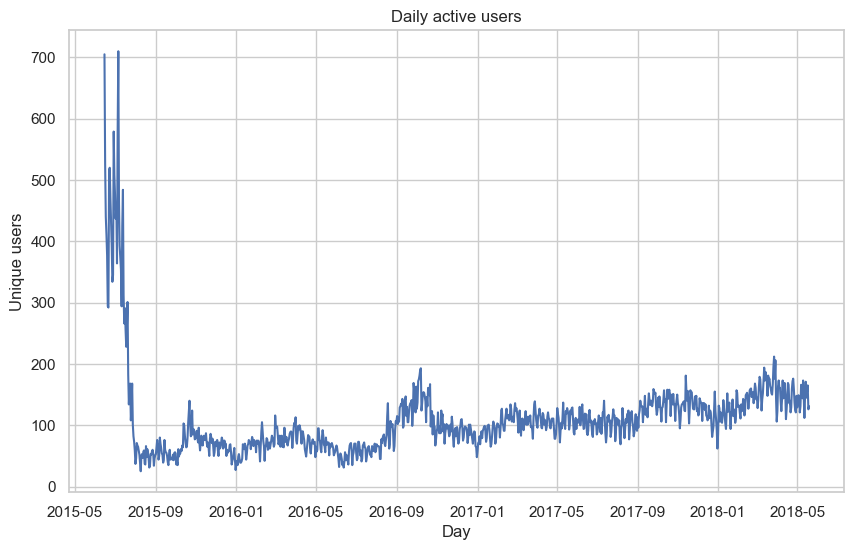

In [20]:
daily_active_users.plot()
plt.title("Daily active users")
plt.xlabel("Day")
plt.ylabel("Unique users")
plt.show()

## 3. EDA: какие действия совершают пользователи

In [21]:
events_train["action"].value_counts()

action
viewed             1830830
discovered          689495
passed              650331
started_attempt     310047
Name: count, dtype: int64

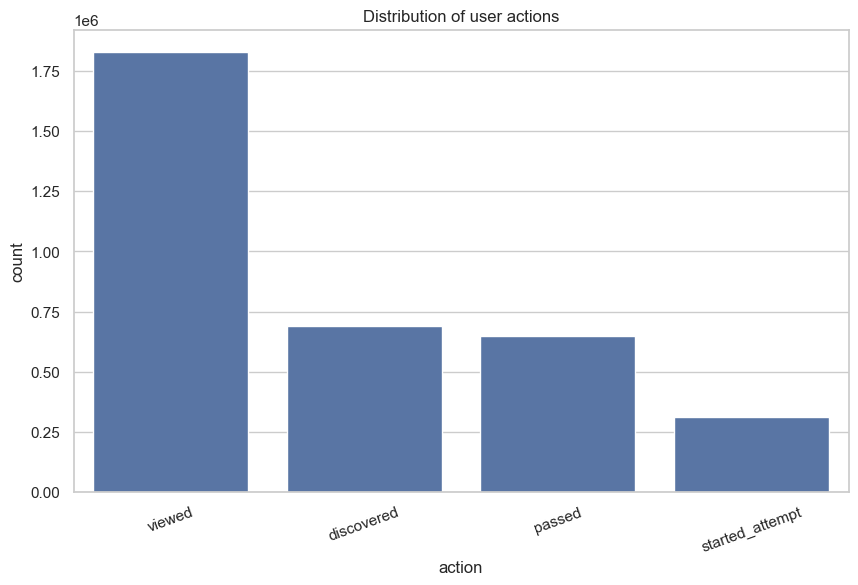

In [22]:
sns.countplot(data=events_train, x="action", order=events_train["action"].value_counts().index)
plt.title("Distribution of user actions")
plt.xticks(rotation=20)
plt.show()

## 4. Целевая переменная
Считаю, что пользователь **прошёл курс**, если у него больше 170 событий `passed`.

In [23]:
course_result = (
    events_train[events_train["action"] == "passed"]
    .groupby("user_id")["step_id"]
    .count()
    .reset_index(name="passed_steps")
)

course_result["passed_course"] = course_result["passed_steps"] > 170
course_result["passed_course"].value_counts()

passed_course
False    15837
True      1425
Name: count, dtype: int64

In [24]:
# добавим пользователей, у которых passed_steps = 0
all_users = pd.DataFrame({"user_id": events_train["user_id"].unique()})

course_result = (
    all_users.merge(course_result, on="user_id", how="left")
    .fillna({"passed_steps": 0, "passed_course": False})
)

course_result["passed_course"] = course_result["passed_course"].astype(int)
course_result["passed_course"].value_counts(normalize=True)

C:\Users\F8902\AppData\Local\Temp\ipykernel_8500\3894685044.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna({"passed_steps": 0, "passed_course": False})


passed_course
0    0.925912
1    0.074088
Name: proportion, dtype: float64

## 5. Feature engineering
Для каждого пользователя беру только первые 3 дня активности и строю признаки.
Такой подход ближе к реальной задаче раннего прогноза.

In [25]:
first_user_days = events_train.groupby("user_id")["timestamp"].min().reset_index(name="first_timestamp")
events_train = events_train.merge(first_user_days, on="user_id", how="left")
submissions_train = submissions_train.merge(first_user_days, on="user_id", how="left")

three_days = 3 * 24 * 60 * 60

events_3d = events_train[events_train["timestamp"] <= events_train["first_timestamp"] + three_days].copy()
submissions_3d = submissions_train[submissions_train["timestamp"] <= submissions_train["first_timestamp"] + three_days].copy()

print(events_3d.shape, submissions_3d.shape)

(1014985, 7) (135599, 7)


In [26]:
event_features = (
    events_3d.pivot_table(
        index="user_id",
        columns="action",
        values="step_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

event_features.head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,9
2,3,15,15,4,20
3,5,1,1,0,1
4,7,1,1,0,1


In [27]:
submission_features = (
    submissions_3d.pivot_table(
        index="user_id",
        columns="submission_status",
        values="step_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

submission_features.head()

submission_status,user_id,correct,wrong
0,2,2,0
1,3,4,4
2,8,9,21
3,14,0,1
4,16,23,27


In [28]:
days_active_3d = events_3d.groupby("user_id")["day"].nunique().reset_index(name="days_active_3d")
unique_steps_3d = events_3d.groupby("user_id")["step_id"].nunique().reset_index(name="unique_steps_3d")
last_timestamp_3d = events_3d.groupby("user_id")["timestamp"].max().reset_index(name="last_timestamp_3d")

features = all_users.merge(event_features, on="user_id", how="left")
features = features.merge(submission_features, on="user_id", how="left")
features = features.merge(days_active_3d, on="user_id", how="left")
features = features.merge(unique_steps_3d, on="user_id", how="left")
features = features.merge(last_timestamp_3d, on="user_id", how="left")

features = features.fillna(0)
features.head()

,user_id,discovered,passed,started_attempt,viewed,correct,wrong,days_active_3d,unique_steps_3d,last_timestamp_3d
0,17632,50,36,15,178,8.0,24.0,3,50,1434565810
1,12494,17,14,1,24,0.0,0.0,2,17,1434438963
2,442,23,23,10,54,7.0,23.0,3,23,1434600329
3,22254,35,35,14,58,12.0,26.0,4,35,1434599310
4,6646,2,2,0,3,0.0,0.0,1,2,1434342234


## 6. Собираю итоговую таблицу для модели

In [29]:
dataset = features.merge(course_result[["user_id", "passed_course"]], on="user_id", how="left")
dataset["passed_course"] = dataset["passed_course"].fillna(0).astype(int)

print(dataset.shape)
dataset["passed_course"].value_counts()

(19234, 11)


passed_course
0    17809
1     1425
Name: count, dtype: int64

In [30]:
dataset.head()

,user_id,discovered,passed,started_attempt,viewed,correct,wrong,days_active_3d,unique_steps_3d,last_timestamp_3d,passed_course
0,17632,50,36,15,178,8.0,24.0,3,50,1434565810,0
1,12494,17,14,1,24,0.0,0.0,2,17,1434438963,0
2,442,23,23,10,54,7.0,23.0,3,23,1434600329,0
3,22254,35,35,14,58,12.0,26.0,4,35,1434599310,0
4,6646,2,2,0,3,0.0,0.0,1,2,1434342234,1


## 7. Baseline model
Использую логистическую регрессию.  
Перед обучением:
- `SimpleImputer` заполняет возможные пропуски;
- `StandardScaler` приводит признаки к сопоставимому масштабу.

In [31]:
feature_columns = [col for col in dataset.columns if col not in ["user_id", "passed_course"]]

X = dataset[feature_columns].copy()
y = dataset["passed_course"].copy()

print("Target distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Target distribution:
passed_course
0    17809
1     1425
Name: count, dtype: int64
passed_course
0    0.925912
1    0.074088
Name: proportion, dtype: float64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train target distribution:")
print(y_train.value_counts())

print("Test target distribution:")
print(y_test.value_counts())

Train target distribution:
passed_course
0    14247
1     1140
Name: count, dtype: int64
Test target distribution:
passed_course
0    3562
1     285
Name: count, dtype: int64


In [33]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      3562
           1       0.26      0.73      0.39       285

    accuracy                           0.83      3847
   macro avg       0.62      0.78      0.64      3847
weighted avg       0.92      0.83      0.86      3847

ROC-AUC: 0.851805116384448


## Выводы

1. Поведенческие признаки пользователей оказались полезными для задачи классификации: по активности на платформе можно предсказывать вероятность завершения курса.
2. После агрегации событий и отправок решений удалось получить информативные признаки: число просмотров, попыток, правильных и неправильных ответов, активных дней и уникальных шагов.
3. Логистическая регрессия показала, что даже простая baseline-модель улавливает зависимость между поведением пользователя и итогом прохождения курса.
4. По метрике ROC-AUC модель показала хороший результат (0.8518), значит построенные признаки действительно содержат полезный сигнал.
5. При этом модель лучше распознаёт пользователей, не завершивших курс, чем пользователей, успешно прошедших его.
6. Проект можно улучшить за счёт более сильных моделей, новых признаков и настройки порога классификации.